In [ ]:
# @title Setup (Google Colab) — run me first  { display-mode: "form" }
# --- capstone-colab-bootstrap ---------------------------------------------------------
# Makes this notebook runnable on a fresh Colab VM. On a local machine every
# branch below is skipped, so the cell is a no-op and safe to keep at the top.
import os, subprocess, sys

def _on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

REPO_URL = "https://github.com/OWNER/REPO.git"
REPO_DIR = "/content/NeuroAI_EmbodiedAi_Capstone"

if _on_colab():
    if not os.path.isdir(REPO_DIR):
        # --recurse-submodules pulls MotorNet (pinned v0.3.0) and nlb_tools with it
        subprocess.run(["git", "clone", "--recurse-submodules", REPO_URL, REPO_DIR], check=True)
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "-e", os.path.join(REPO_DIR, "MotorNet")], check=True)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "numpy", "scipy", "scikit-learn", "matplotlib"], check=True)

    # Trained weights / neural datasets are NOT in git (see README "Data and weights").
    # Mount Drive if you want to reuse or save checkpoints; training works without it.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE = "/content/drive/MyDrive/neuroai_capstone"
        os.makedirs(DRIVE, exist_ok=True)
        os.environ["CAPSTONE_DRIVE"] = DRIVE
        print("Drive ready ->", DRIVE)
    except Exception as e:
        print("Drive not mounted (training still works, checkpoints stay on the VM):", e)

# `notebooks/` must be importable for motor_core / motor_zoo / plausible_learners
sys.path.insert(0, os.getcwd())

import torch as th
print("torch", th.__version__, "| CUDA", th.cuda.is_available(),
      "|", th.cuda.get_device_name(0) if th.cuda.is_available() else "CPU")
if not th.cuda.is_available():
    print("WARNING: no GPU. Colab: Runtime > Change runtime type > T4 GPU.")


# Microcircuit analysis of the trained motor controllers

This is the companion to `4-train-net.ipynb`. That notebook *trained* thirteen controllers on the
MotorNet reaching task and saved their weights to `save/models/`. This notebook *opens them up* and
asks what their internal microcircuits actually compute — for **both the trained models and the
problem environment they were trained on**, as requested.

The analysis adapts three canonical microcircuit computations from the **Neuromatch NeuroAI W1D5
"Microcircuits" tutorials** and applies them to motor control, then adds the classic motor-cortex
toolkit:

| Section | Adapted from | Question |
|---|---|---|
| **1 · The plant's microcircuit** | — | What are the muscle synergies and the 4→2 redundancy the controllers must master? |
| **2 · Sparsity & sparse coding** | W1D5 **Tutorial 1** (Sparsity) | How sparse are the hidden codes? Kurtosis, population sparseness, temporal differencing, dictionary learning, OMP. |
| **3 · Normalization** | W1D5 **Tutorial 2** (Normalization) | Do the circuits implement divisive gain control $g\mathbf{x}/(\sigma+\lVert\mathbf{x}\rVert_p)$? |
| **4 · Gain modulation** | W1D5 **Tutorial 3** (Attention) | Does the goal *multiplicatively* gate proprioceptive processing, as attention would predict? |
| **5 · Neural dynamics** | Sussillo & Barak 2013 | Neural manifolds, fixed points, Jacobian stability of the recurrent controllers. |
| **6 · Directional tuning** | Georgopoulos et al. 1982 | Cosine tuning and the population vector — does the hidden code point at the target? |
| **7 · Lesions** | — | How distributed / robust is each controller under unit ablation? |
| **8 · Synthesis** | — | Which internal-code properties actually predict motor competence? |

Everything runs on the **saved weights** — nothing is retrained. If `save/models/` is missing, run
`4-train-net.ipynb` section VIII first. Architectures are reconstructed from `motor_zoo.py`, which is
generated from the very same cell sources as the training notebook, so the classes match the
checkpoints exactly.

In [1]:
# ==============================================================================
# 0. Setup: the plant, the trained models, and an activity probe  (fair-redo models)
# ------------------------------------------------------------------------------
# Microcircuit analysis of the controllers from 4-train-net.ipynb (FAIR redo: all share
# the KINESIS force head). Loads save/models/*.pt and reconstructs each architecture from
# motor_zoo.py (generated from the same cell sources, so classes match the checkpoints).
# Three architecture families: GRU policies (bptt_gru, shac, kinesis), demonstration-bootstrapped
# recurrent deep-RL (sac, fasttd3, simbav2 -- GRUCell actor warm-started from the demonstrator),
# and fixed-reservoir + local readout (the 6 plausible rules +
# dendritron). The reservoir rules imitate a demonstrator, so their checkpoints carry a
# `teacher.*` submodule -> we build them with a placeholder demonstrator and load
# strict=False (the checkpoint overwrites it).
# ==============================================================================
import os, sys, json, math
import numpy as np
import torch as th
import matplotlib as mpl, matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../MotorNet")); sys.path.append(os.path.abspath("."))
import motornet as mn
from motor_zoo import (DEVICE, make_env, ReachEnv, env_to, obs_norm, rollout, evaluate,
                       eval_metrics, Probe, SUCCESS_CM, MODEL_DIR, force_head, MorphGRU,
                       BPTTGRU, SHAC, SAC, FastTD3, SimbaV2, EProp, RTRRL, BTSP,
                       Kinesis, RSTDP, PredictiveCoding, Hebb3, Dendritron)

th.manual_seed(0)
mpl.rcParams.update({"font.size": 9, "axes.titlesize": 10.5, "axes.titleweight": "bold",
                     "axes.edgecolor": "#8A94A6", "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white",
                     "legend.fontsize": 7.5, "legend.framealpha": .92})
C = dict(goal="#D1495B", vis="#3E7CB1", prop="#3B9C6E", act="#E8A33D",
         ink="#1F2933", mute="#8A94A6", grid="#E4E7EB", grad="#B3541E", loc="#3B9C6E", mod="#6C5CE7")

ENV = make_env(DEVICE)
N_STEPS = int(ENV.max_ep_duration / ENV.dt)

# families ---------------------------------------------------------------------
GRU_TAGS  = {"bptt_gru", "shac", "kinesis"}                    # recurrent GRU hidden state
MLP_TAGS  = {"sac", "fasttd3", "simbav2"}   # now RECURRENT demonstration-bootstrapped (GRUCell hidden)
RES_TAGS  = {"eprop", "rtrrl", "btsp", "rstdp", "predcode", "hebb3", "dendritron"}  # reservoir state
ZOO = {t: cls for t, cls in [("bptt_gru", BPTTGRU), ("shac", SHAC), ("sac", SAC),
       ("fasttd3", FastTD3), ("simbav2", SimbaV2), ("eprop", EProp), ("rtrrl", RTRRL),
       ("btsp", BTSP), ("kinesis", Kinesis), ("rstdp", RSTDP), ("predcode", PredictiveCoding),
       ("hebb3", Hebb3), ("dendritron", Dendritron)]}

def load_model(tag):
    cls = ZOO[tag]
    _tch = MorphGRU(ENV) if tag in RES_TAGS else BPTTGRU(ENV)   # RES rules trained on RAW-3 morph teacher; RL bootstrap on RAW-4 muscle
    m = cls(ENV, teacher=_tch) if (tag in RES_TAGS or tag in MLP_TAGS) else cls(ENV)
    p = os.path.join(MODEL_DIR, f"{tag}.pt")
    if os.path.exists(p): m.load_state_dict(th.load(p, map_location=DEVICE), strict=False)
    m.eval(); return m

def load_meta():
    idx = os.path.join(MODEL_DIR, "index.json")
    return {d["tag"]: d for d in json.load(open(idx))} if os.path.exists(idx) else {}

MODELS_PRESENT = os.path.isdir(MODEL_DIR) and any(f.endswith(".pt") for f in os.listdir(MODEL_DIR)) if os.path.isdir(MODEL_DIR) else False
if MODELS_PRESENT:
    META = load_meta(); TAGS = [t for t in ZOO if os.path.exists(os.path.join(MODEL_DIR, f"{t}.pt"))]
    print(f"loaded {len(TAGS)} trained models from {MODEL_DIR}/:")
    for t in TAGS:
        print(f"  {t:12s} {META.get(t,{}).get('name','?'):40s} acc={META.get(t,{}).get('acc',float('nan')):.1f} cm")
else:
    TAGS, META = [], {}; print(f"!! no models in {MODEL_DIR}/ -- run 4-train-net.ipynb section VIII first.")


# ---- hidden-activity grabber, one per architecture family --------------------
def _hidden_grabber(model, tag):
    """f(model, obs, state) -> (B, H) characteristic microcircuit activity.
    GRU policies -> recurrent hidden state; reservoir rules -> reservoir state;
    model-free MLP -> penultimate actor activation."""
    def gru_h(m, obs, st):  return st[0].detach() if th.is_tensor(st) and st.dim() == 3 else None
    def res_h(m, obs, st):  return st.detach() if th.is_tensor(st) and st.dim() == 2 else None
    def mlp_penult(m, obs, st):
        h = (obs - m.mu) / m.sig
        for layer in list(m.actor)[:-1]: h = layer(h)
        return h.detach()
    def simba_h(m, obs, st):
        net = m.actor; x = net.inp((obs - m.mu) / m.sig)
        for b in net.blocks: x = b(x)
        return x.detach()
    if tag in GRU_TAGS or tag in MLP_TAGS: return gru_h        # deep-RL now recurrent (GRUCell)
    if tag in RES_TAGS: return res_h
    return gru_h

@th.no_grad()
def collect(model, tag, seed=None, batch=64, step_kwargs=None):
    """Deterministic rollout; returns dict(obs, act, hid (T,B,H), dist, xy, tg)."""
    step_kwargs = step_kwargs or {}
    obs, info = ENV.reset(seed=(seed if seed is not None else 20260717),
                          options={"batch_size": batch, "deterministic": True})
    st = model.init_state(batch); grab = _hidden_grabber(model, tag)
    O, A_, H, D, XY = [obs], [], [], [], [info["states"]["fingertip"]]; tg = info["goal"]
    for t in range(N_STEPS):
        a, st = model.act(obs, st, explore=False)
        H.append(grab(model, obs, st))
        obs, r, term, trunc, info = ENV.step(a, deterministic=True, **step_kwargs)
        A_.append(a); D.append(info["dist"]); O.append(obs); XY.append(info["states"]["fingertip"])
    stack = lambda L: th.stack(L, 0)
    return dict(obs=stack(O[:-1]).cpu(), act=stack(A_).cpu(),
                hid=stack(H).cpu() if H[0] is not None else None,
                dist=th.cat(D, 1).cpu(), xy=stack(XY).cpu(), tg=tg.cpu())

print(f"\nplant: ReluPointMass24 + RandomTargetReach | {N_STEPS} steps x {ENV.dt*1000:.0f} ms | device {DEVICE}")

loaded 13 trained models from save/models/:
  bptt_gru     BPTT-GRU (MotorNet muscle head)          acc=1.6 cm
  shac         SHAC (MotorNet muscle head)              acc=1.2 cm
  sac          SAC (MotorNet muscle head, expert-RB)    acc=0.9 cm
  fasttd3      FastTD3 (MotorNet muscle head, expert-RB) acc=1.1 cm
  simbav2      Simba (MotorNet muscle head, expert-RB)  acc=0.9 cm
  eprop        e-prop (ALIF reservoir · eligibility trace + learning signal) acc=4.6 cm
  rtrrl        RTRRL / RFLO (real-time local · random feedback) acc=4.4 cm
  btsp         BTSP (plateau-gated one-shot · behavioural-timescale trace) acc=6.3 cm
  kinesis      KINESIS (morphological force control)    acc=29.5 cm
  rstdp        R-STDP (spiking eligibility · reward-modulated STDP tag) acc=4.3 cm
  predcode     Predictive coding (hierarchical error-unit inference) acc=5.0 cm
  hebb3        3-factor Hebb (reward-gated neuromodulatory plasticity) acc=4.2 cm
  dendritron   Dendritron (frozen experts + router)     ac

## 1 · The plant's microcircuit: muscle synergies & task geometry

Before the controllers, the thing they control. The plant's own microcircuit is its muscle geometry — four one-sided pullers spanning 2-D force — and the muscle **synergies** (motor primitives) that emerge from coordinating them.

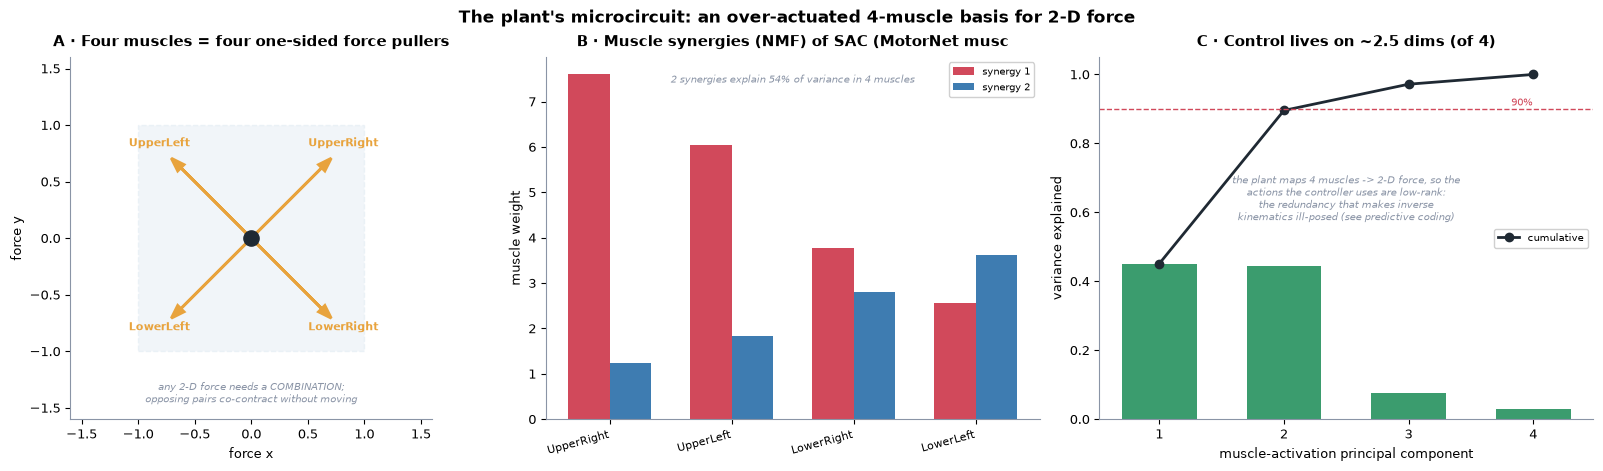

muscle synergies from 'sac': 2-synergy NMF reconstructs 54% of activation variance; action participation ratio = 2.45/4


In [2]:
# ==============================================================================
# 1. The environment as a microcircuit: muscle synergies and task geometry
# ------------------------------------------------------------------------------
# Before analysing the controllers, analyse what they are controlling. The user asked
# for microcircuit analysis of "both the models and the problem environment". The
# plant's own microcircuit is its MUSCLE GEOMETRY: four one-sided pullers spanning a
# 2-D force space. That over-actuation is the substrate every controller has to learn
# to coordinate, and it is where "muscle synergies" -- the motor-primitives idea from
# the sparse-coding tutorial (W1D5-T1) -- come from.
#
# We (a) map the force each muscle can exert, (b) extract muscle synergies by NMF of
# the executed activations (non-negative, like the muscles themselves), and (c) show
# the 4->2 redundancy that makes an inverse model ill-posed (why VIII.11's predictive
# coding had to INFER the command rather than regress it).
# ==============================================================================
from sklearn.decomposition import NMF, PCA
import matplotlib.patches as mpatches

# --- the plant's force geometry: each muscle pulls toward its anchor -----------
eff = ENV.effector
anchors = eff._path_coordinates[0, :, 0::2].T          # (4, 2), muscle order
names = list(eff.muscle_name)
Fmax = float(eff.muscle.max_iso_force.mean())          # 500 N

fig = plt.figure(figsize=(16, 4.6), constrained_layout=True)
gs = fig.add_gridspec(1, 3)

# A · force directions ---------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
ax.add_patch(mpatches.Rectangle((-1, -1), 2, 2, fc=C["vis"], alpha=.07, ec=C["vis"], ls="--"))
for (ax_, ay), nm in zip(anchors, names):
    u = np.array([ax_, ay]); u = u / np.linalg.norm(u)     # pull direction from origin
    ax.arrow(0, 0, u[0], u[1], head_width=.08, color=C["act"], lw=2, length_includes_head=True)
    ax.annotate(nm, (u[0]*1.15, u[1]*1.15), ha="center", fontsize=8, color=C["act"], fontweight="bold")
ax.scatter([0], [0], s=120, c=C["ink"], zorder=5)
ax.set(xlim=(-1.6, 1.6), ylim=(-1.6, 1.6), xlabel="force x", ylabel="force y", aspect="equal")
ax.set_title("A · Four muscles = four one-sided force pullers", pad=8)
ax.text(0, -1.45, "any 2-D force needs a COMBINATION;\nopposing pairs co-contract without moving",
        ha="center", fontsize=7, color=C["mute"], style="italic")

# B · muscle synergies by NMF of a good controller's activations ----------------
best_tag = min(TAGS, key=lambda t: META.get(t, {}).get("acc", 1e9)) if TAGS else "bptt_gru"
d = collect(load_model(best_tag), best_tag, batch=256)
A = d["act"].reshape(-1, 4).numpy()                    # (T*B, 4), non-negative
A = A[A.sum(1) > 1e-3]                                  # drop silent steps
nmf = NMF(n_components=2, init="nndsvda", max_iter=500, random_state=0).fit(A)
syn = nmf.components_                                   # (2, 4): the two synergies
recon_err = 1 - ((A - nmf.inverse_transform(nmf.transform(A)))**2).sum() / ((A - A.mean(0))**2).sum()
ax = fig.add_subplot(gs[0, 1])
xw = np.arange(4)
ax.bar(xw - .17, syn[0], .34, color=C["goal"], label="synergy 1")
ax.bar(xw + .17, syn[1], .34, color=C["vis"], label="synergy 2")
ax.set_xticks(xw); ax.set_xticklabels(names, rotation=15, ha="right", fontsize=8)
ax.set(ylabel="muscle weight"); ax.legend()
ax.set_title(f"B · Muscle synergies (NMF) of {META.get(best_tag,{}).get('name',best_tag)[:18]}", pad=8)
ax.text(.5, .93, f"2 synergies explain {100*recon_err:.0f}% of variance in 4 muscles",
        transform=ax.transAxes, ha="center", fontsize=7.5, color=C["mute"], style="italic")

# C · the 4->2 redundancy: activation PCA spectrum ------------------------------
ax = fig.add_subplot(gs[0, 2])
pca = PCA().fit(A)
ev = pca.explained_variance_ratio_
ax.bar(np.arange(1, 5), ev, .6, color=C["prop"])
ax.plot(np.arange(1, 5), np.cumsum(ev), "-o", color=C["ink"], lw=2, label="cumulative")
ax.axhline(0.9, color=C["goal"], ls="--", lw=1); ax.text(4, .91, "90%", color=C["goal"], fontsize=7, ha="right")
pr_dim = (ev.sum()**2) / (ev**2).sum()
ax.set(xlabel="muscle-activation principal component", ylabel="variance explained", ylim=(0, 1.05))
ax.set_xticks([1, 2, 3, 4]); ax.legend(loc="center right")
ax.set_title(f"C · Control lives on ~{pr_dim:.1f} dims (of 4)", pad=8)
ax.text(.5, .55, "the plant maps 4 muscles -> 2-D force, so the\nactions the controller uses are low-rank:\n"
                 "the redundancy that makes inverse\nkinematics ill-posed (see predictive coding)",
        transform=ax.transAxes, ha="center", fontsize=7, color=C["mute"], style="italic")

fig.suptitle("The plant's microcircuit: an over-actuated 4-muscle basis for 2-D force",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"muscle synergies from '{best_tag}': 2-synergy NMF reconstructs {100*recon_err:.0f}% of activation variance; "
      f"action participation ratio = {pr_dim:.2f}/4")

## 2 · Sparsity & sparse coding  *(adapts W1D5 Tutorial 1)*

Kurtosis and population sparseness of the hidden codes; whether temporal differencing sparsifies the control signal; and a learned **dictionary of motor atoms** whose sparse combinations reconstruct the hidden trajectories (with OMP reconstruction of the commands).

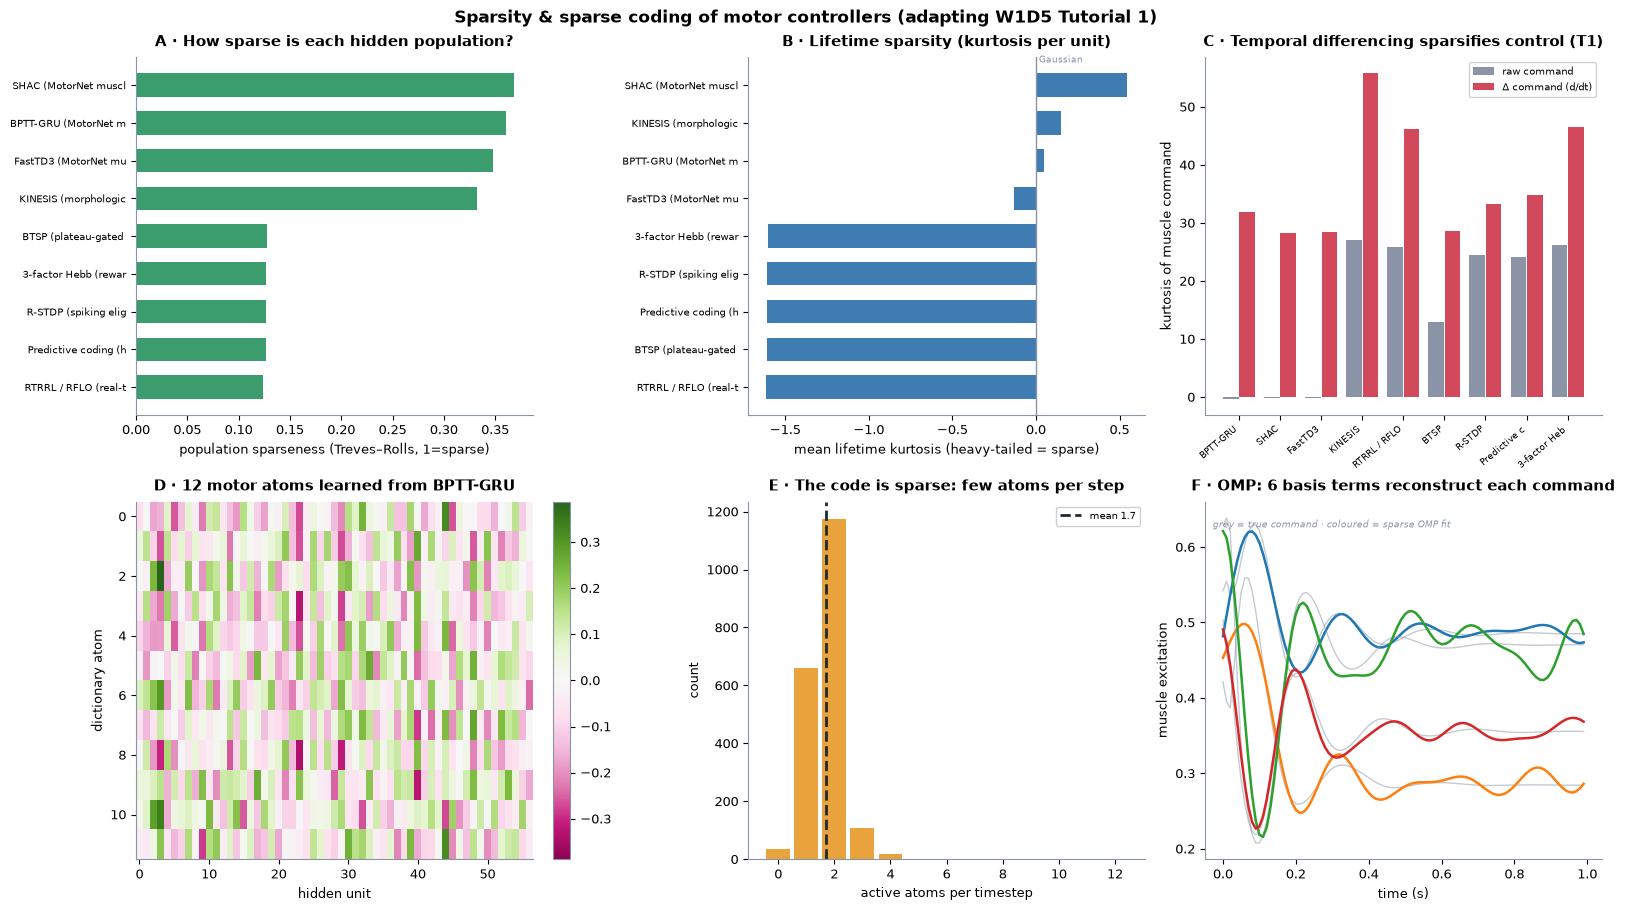

sparsest population: SHAC (MotorNet muscle head) (pop-sparseness 0.37); temporal differencing raised mean command kurtosis 15.5 -> 37.1; BPTT-GRU hidden code uses 1.7/12 atoms per step


In [3]:
# ==============================================================================
# 2. Sparsity & sparse coding  (adapts Neuromatch W1D5 Tutorial 1)
# ------------------------------------------------------------------------------
#   Tutorial 1 teaches: quantify sparsity by KURTOSIS; sparsity arises from
#   thresholding and from temporal differencing; find sparse codes with
#   OrthogonalMatchingPursuit; and learn an overcomplete dictionary of atoms with
#   sklearn DictionaryLearning. We apply all four to the trained controllers.
#
#   For a motor microcircuit the questions are:
#     * How sparse is each model's hidden population? (population & lifetime sparseness,
#       kurtosis) -- sparse codes are the biologically-favoured regime.
#     * Does temporal differencing of the control signal increase sparsity, as it does
#       for natural signals? (T1's temporal-differentiation result)
#     * Can we learn a small DICTIONARY of "motor atoms" whose sparse combinations
#       reconstruct the hidden trajectories -- the dictionary-learning exercise, but on
#       a motor RNN instead of natural-image frames?
# ==============================================================================
from scipy.stats import kurtosis
from sklearn.decomposition import DictionaryLearning
from sklearn.linear_model import OrthogonalMatchingPursuit
names = list(ENV.effector.muscle_name)                 # muscle order, independent of section 1

def population_sparseness(H):
    """Treves-Rolls / Vinje-Gallant sparseness of a (samples, units) activity matrix,
    averaged over samples. 1 = maximally sparse (one unit active), 0 = dense."""
    x = np.abs(H); n = x.shape[1]
    num = (x.mean(1)) ** 2
    den = (x ** 2).mean(1) + 1e-12
    return float((1 - num / den).mean() / (1 - 1.0 / n))

ANALYSE = [t for t in ["bptt_gru", "shac", "fasttd3", "kinesis", "eprop", "rtrrl",
                       "btsp", "rstdp", "predcode", "hebb3"] if t in TAGS]

rows = []
for tag in ANALYSE:
    d = collect(load_model(tag), tag, batch=128)
    if d["hid"] is None: continue
    H = d["hid"].reshape(-1, d["hid"].shape[-1]).numpy()
    H = H[:, H.std(0) > 1e-6]                                  # drop dead units
    if H.shape[1] < 2: continue
    pop = population_sparseness(H)
    life_k = float(np.nanmean(kurtosis(H, axis=0, fisher=True)))   # lifetime kurtosis per unit
    # temporal differencing (T1): does d/dt sparsify the control?
    a = d["act"].numpy().reshape(d["act"].shape[0], d["act"].shape[1], 4)
    k_raw = float(np.nanmean(kurtosis(a.reshape(-1, 4), axis=0)))
    k_diff = float(np.nanmean(kurtosis(np.diff(a, axis=0).reshape(-1, 4), axis=0)))
    rows.append(dict(tag=tag, name=META.get(tag, {}).get("name", tag), pop=pop,
                     life_k=life_k, k_raw=k_raw, k_diff=k_diff, H=H))

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# A · population sparseness ----------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
o = sorted(range(len(rows)), key=lambda i: rows[i]["pop"])
ax.barh(range(len(o)), [rows[i]["pop"] for i in o], .62, color=C["prop"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([rows[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("population sparseness (Treves–Rolls, 1=sparse)")
ax.set_title("A · How sparse is each hidden population?", pad=8)

# B · lifetime kurtosis --------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
o = sorted(range(len(rows)), key=lambda i: rows[i]["life_k"])
ax.barh(range(len(o)), [rows[i]["life_k"] for i in o], .62, color=C["vis"])
ax.axvline(0, color=C["mute"], lw=1); ax.text(0, len(o)-.4, " Gaussian", fontsize=6.5, color=C["mute"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([rows[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("mean lifetime kurtosis (heavy-tailed = sparse)")
ax.set_title("B · Lifetime sparsity (kurtosis per unit)", pad=8)

# C · temporal differencing sparsifies the control -----------------------------
ax = fig.add_subplot(gs[0, 2])
xg = np.arange(len(rows))
ax.bar(xg - .2, [r["k_raw"] for r in rows], .38, color=C["mute"], label="raw command")
ax.bar(xg + .2, [r["k_diff"] for r in rows], .38, color=C["goal"], label="Δ command (d/dt)")
ax.set_xticks(xg); ax.set_xticklabels([r["name"].split(" (")[0][:12] for r in rows], rotation=40, ha="right", fontsize=6.5)
ax.set_ylabel("kurtosis of muscle command"); ax.legend()
ax.set_title("C · Temporal differencing sparsifies control (T1)", pad=8)

# D-F · dictionary learning of "motor atoms" on the best recurrent model --------
rec = next((r for r in rows if r["tag"] in ("bptt_gru", "kinesis")), rows[0])
H = rec["H"]
H = H[np.random.RandomState(0).choice(H.shape[0], min(2000, H.shape[0]), replace=False)]
K = 12
dl = DictionaryLearning(n_components=K, transform_algorithm="lasso_lars",
                        transform_alpha=0.5, max_iter=60, random_state=0).fit(H)
codes = dl.transform(H)                                       # sparse coefficients
atoms = dl.components_                                        # (K, hidden)
active_per_sample = (np.abs(codes) > 1e-3).sum(1).mean()

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(atoms, aspect="auto", cmap="PiYG", vmin=-np.abs(atoms).max(), vmax=np.abs(atoms).max())
ax.set(xlabel="hidden unit", ylabel="dictionary atom")
ax.set_title(f"D · {K} motor atoms learned from {rec['name'].split(' (')[0]}", pad=8)
fig.colorbar(im, ax=ax, fraction=.046)

ax = fig.add_subplot(gs[1, 1])
ax.hist((np.abs(codes) > 1e-3).sum(1), bins=np.arange(0, K+2)-.5, color=C["act"], rwidth=.85)
ax.axvline(active_per_sample, color=C["ink"], lw=2, ls="--", label=f"mean {active_per_sample:.1f}")
ax.set(xlabel="active atoms per timestep", ylabel="count"); ax.legend()
ax.set_title("E · The code is sparse: few atoms per step", pad=8)

# F · OMP reconstruction of the muscle command from a synergy dictionary --------
ax = fig.add_subplot(gs[1, 2])
d = collect(load_model(rec["tag"]), rec["tag"], batch=1)
sig = d["act"][:, 0, :].numpy()                              # (T, 4) command of one reach
# frequency basis (T1's OMP exercise) reconstructing each muscle channel
T = sig.shape[0]; tarr = np.arange(T)
freqs = np.linspace(0.001, 1.0, 60)
basis = np.vstack([np.sin(tarr * f) for f in freqs] + [np.cos(tarr * f) for f in freqs]).T
for m in range(4):
    card = 6
    reg = OrthogonalMatchingPursuit(n_nonzero_coefs=card, fit_intercept=True).fit(basis, sig[:, m])
    ax.plot(tarr * ENV.dt, sig[:, m], color=C["mute"], lw=1, alpha=.5)
    ax.plot(tarr * ENV.dt, reg.predict(basis), lw=1.8, label=names[m] if m == 0 else None)
ax.set(xlabel="time (s)", ylabel="muscle excitation")
ax.set_title(f"F · OMP: {card} basis terms reconstruct each command", pad=8)
ax.text(.02, .95, "grey = true command · coloured = sparse OMP fit", transform=ax.transAxes,
        fontsize=6.8, color=C["mute"], va="top", style="italic")

fig.suptitle("Sparsity & sparse coding of motor controllers (adapting W1D5 Tutorial 1)",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"sparsest population: {rows[int(np.argmax([r['pop'] for r in rows]))]['name']} "
      f"(pop-sparseness {max(r['pop'] for r in rows):.2f}); "
      f"temporal differencing raised mean command kurtosis "
      f"{np.mean([r['k_raw'] for r in rows]):.1f} -> {np.mean([r['k_diff'] for r in rows]):.1f}; "
      f"{rec['name'].split(' (')[0]} hidden code uses {active_per_sample:.1f}/{K} atoms per step")

## 3 · Normalization  *(adapts W1D5 Tutorial 2)*

Does a controller respond **compressively** to input magnitude — the signature of divisive normalization / gain control — or merely proportionally? We fit Tutorial 2's divisive operator to each circuit's input–output gain.

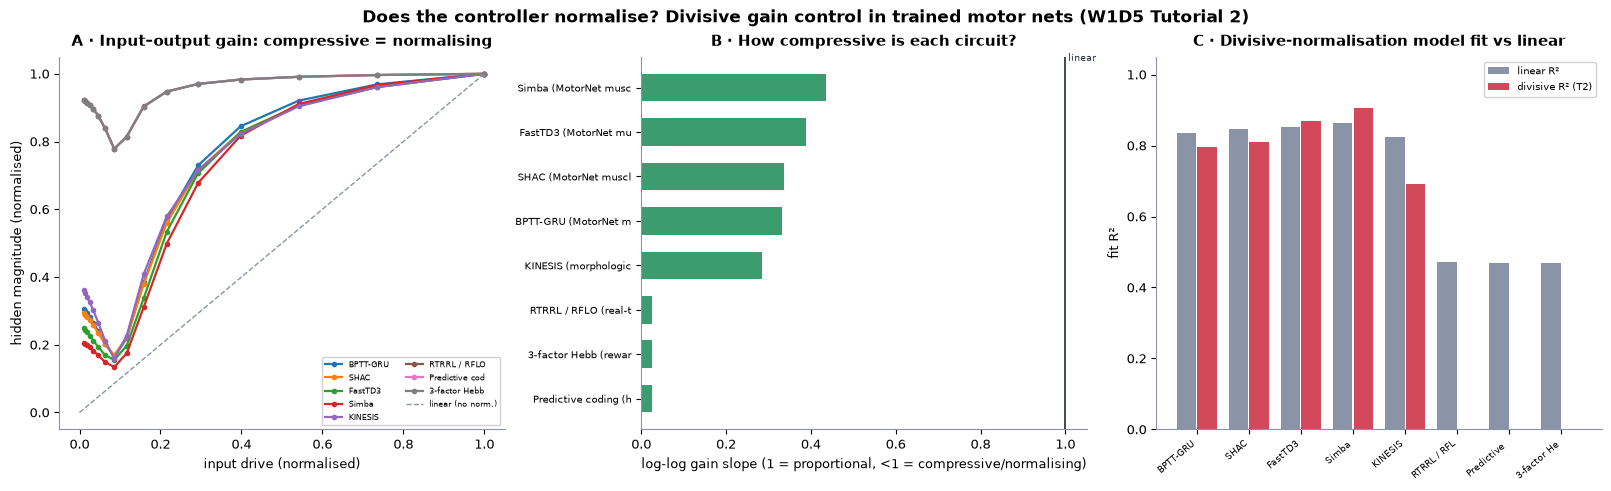

most compressive / normalising circuit: Predictive coding (hierarchical error-unit inference) (log-log slope 0.02); divisive model beats linear for 1/8 models


In [4]:
# ==============================================================================
# 3. Normalization  (adapts Neuromatch W1D5 Tutorial 2)
# ------------------------------------------------------------------------------
#   Tutorial 2's divisive-normalization operator, verbatim:
#       normalize(x, sigma, p, g) = g * x / ( sigma + (sum_i |x_i|^p)^(1/p) )
#   and its central lesson: a normalizing circuit responds COMPRESSIVELY to input
#   magnitude (it recovers a latent property invariant to overall scale), whereas a
#   plain linear map responds proportionally.
#
#   Motor question: does a trained controller normalise? We probe it exactly as T2
#   probes latent-property recovery under scaling. We take the held-out observations,
#   SCALE the proprioceptive+visual channels by a factor s over two orders of
#   magnitude, and measure the hidden population's response magnitude. Then we fit both
#   a linear law and T2's divisive law to (input drive -> output magnitude) and compare
#   R^2. A high divisive R^2 with clear saturation means the microcircuit implements
#   gain control; a linear fit means it does not. Architectures with explicit
#   normalisation (Simba's LayerNorm) should sit at the compressive extreme.
# ==============================================================================
from scipy.optimize import curve_fit

def divisive(x, sigma, g):        # T2 operator, p=2, applied to a scalar drive magnitude
    return g * x / (sigma + x)

@th.no_grad()
def gain_curve(model, tag, scales):
    """Mean hidden-population magnitude as the sensory input is scaled by each s."""
    grab = _hidden_grabber(model, tag)
    obs0, info = ENV.reset(seed=20260717, options={"batch_size": 128, "deterministic": True})
    drive, out = [], []
    for s in scales:
        o = obs0.clone()
        o[:, 4:12] = o[:, 4:12] * s                      # scale proprioception + (indirectly) drive
        st = model.init_state(128)
        _a, st2 = model.act(o, st, explore=False)        # STEP the model so the hidden responds to o
        h = grab(model, o, st2)                          # (every family is recurrent now -> grab post-step)
        if h is None: return None, None
        h = h.reshape(h.shape[0], -1) if h.dim() >= 2 else h.reshape(1, -1)
        drive.append(float((o[:, 4:12].abs().mean())))
        out.append(float(h.abs().mean()))
    return np.array(drive), np.array(out)

scales = np.logspace(-1.0, 1.0, 16)                      # 0.1x .. 10x
ANALYSE = [t for t in ["bptt_gru", "shac", "fasttd3", "simbav2", "kinesis", "eprop",
                       "rtrrl", "predcode", "hebb3"] if t in TAGS]
res = []
for tag in ANALYSE:
    m = load_model(tag)
    dr, ou = gain_curve(m, tag, scales)
    if dr is None or ou.std() < 1e-6: continue
    ou_n = ou / (ou.max() + 1e-9)
    # linear vs divisive fit on normalised drive
    x = dr / (dr.max() + 1e-9)
    lin_r2 = 1 - ((ou_n - np.polyval(np.polyfit(x, ou_n, 1), x))**2).sum() / (((ou_n - ou_n.mean())**2).sum() + 1e-12)
    try:
        (sig_f, g_f), _ = curve_fit(divisive, x, ou_n, p0=[0.3, 1.0], maxfev=5000, bounds=([1e-3, 0], [50, 50]))
        pred = divisive(x, sig_f, g_f)
        div_r2 = 1 - ((ou_n - pred)**2).sum() / (((ou_n - ou_n.mean())**2).sum() + 1e-12)
    except Exception:
        sig_f, g_f, div_r2 = np.nan, np.nan, np.nan
    # compression index: ratio of output range to input range in log-log (1=linear, <1=compressive)
    comp = np.polyfit(np.log(x + 1e-6), np.log(ou_n + 1e-6), 1)[0]
    res.append(dict(tag=tag, name=META.get(tag, {}).get("name", tag), x=x, y=ou_n,
                    sigma=sig_f, div_r2=div_r2, lin_r2=lin_r2, comp=comp))

fig = plt.figure(figsize=(16, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, 3)

# A · gain curves --------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
for r in res:
    ax.plot(r["x"], r["y"], "-o", ms=3, lw=1.6, label=r["name"].split(" (")[0][:14])
ax.plot([0, 1], [0, 1], "--", color=C["mute"], lw=1, label="linear (no norm.)")
ax.set(xlabel="input drive (normalised)", ylabel="hidden magnitude (normalised)")
ax.set_title("A · Input–output gain: compressive = normalising", pad=8)
ax.legend(fontsize=6, ncol=2)

# B · compression exponent (log-log slope) -------------------------------------
ax = fig.add_subplot(gs[0, 1])
o = sorted(range(len(res)), key=lambda i: res[i]["comp"])
ax.barh(range(len(o)), [res[i]["comp"] for i in o], .62,
        color=[C["prop"] if res[i]["comp"] < 0.8 else C["mute"] for i in o])
ax.axvline(1.0, color=C["ink"], lw=1.2); ax.text(1.0, len(o)-.4, " linear", fontsize=6.5, color=C["ink"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("log-log gain slope (1 = proportional, <1 = compressive/normalising)")
ax.set_title("B · How compressive is each circuit?", pad=8)

# C · divisive vs linear fit quality -------------------------------------------
ax = fig.add_subplot(gs[0, 2])
xg = np.arange(len(res))
ax.bar(xg - .2, [r["lin_r2"] for r in res], .38, color=C["mute"], label="linear R²")
ax.bar(xg + .2, [r["div_r2"] for r in res], .38, color=C["goal"], label="divisive R² (T2)")
ax.set_xticks(xg); ax.set_xticklabels([r["name"].split(" (")[0][:11] for r in res], rotation=40, ha="right", fontsize=6.5)
ax.set_ylabel("fit R²"); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("C · Divisive-normalisation model fit vs linear", pad=8)

fig.suptitle("Does the controller normalise? Divisive gain control in trained motor nets (W1D5 Tutorial 2)",
             fontsize=12, fontweight="bold")
plt.show()
most = min(res, key=lambda r: r["comp"])
print(f"most compressive / normalising circuit: {most['name']} (log-log slope {most['comp']:.2f}); "
      f"divisive model beats linear for {sum(r['div_r2'] > r['lin_r2'] + 0.02 for r in res)}/{len(res)} models")

## 4 · Gain modulation & attention  *(adapts W1D5 Tutorial 3)*

Attention gates by **multiplying**. We test whether the goal multiplicatively modulates the proprioception→hidden mapping (a gain field), beyond a purely additive combination.

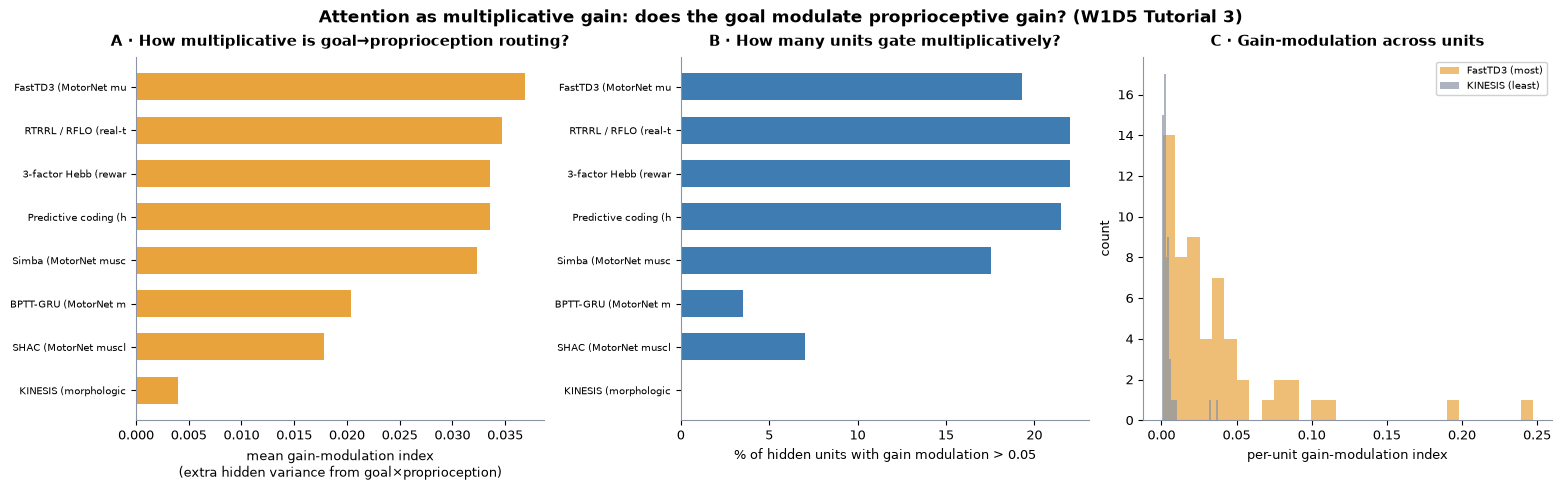

most gain-modulated controller: FastTD3 (MotorNet muscle head, expert-RB) (index 0.037, 19% of units); least: KINESIS (morphological force control) (0.004)


In [5]:
# ==============================================================================
# 4. Gain modulation & attention  (adapts Neuromatch W1D5 Tutorial 3)
# ------------------------------------------------------------------------------
#   Tutorial 3 is about MULTIPLICATIVE interactions: attention gates which inputs
#   matter by multiplying, not adding (gained_dot_product_attention: w = softmax(z*q),
#   y = w . x). Multiplicative gating is the canonical microcircuit motif for flexible,
#   context-dependent routing.
#
#   Motor question: does the GOAL act as a gain that MODULATES how proprioception maps
#   to the hidden state -- i.e. is the goal a multiplicative context, as attention
#   would predict, or merely an additive input? We test this directly. For a hidden
#   unit h, fit two models of its response to (goal g, proprioception p):
#       additive:        h ~ a0 + a1.g + a2.p
#       multiplicative:  h ~ ... + a3.(g (x) p)     (cross / gain terms)
#   The extra variance the cross-terms explain is the GAIN-MODULATION INDEX. A unit
#   whose proprioceptive gain depends on the goal is doing attention-like routing.
# ==============================================================================
from sklearn.linear_model import LinearRegression

@th.no_grad()
def gain_modulation(model, tag, batch=256):
    """Fraction of hidden variance explained by goal x proprioception cross-terms,
    beyond a purely additive goal+proprioception model. Averaged over hidden units."""
    grab = _hidden_grabber(model, tag)
    obs, info = ENV.reset(seed=20260717, options={"batch_size": batch, "deterministic": True})
    st = model.init_state(batch)
    # a couple of steps so proprioception is non-trivial
    for _ in range(5):
        a, st = model.act(obs, st); obs, r, term, trunc, info = ENV.step(a, deterministic=True)
    H = grab(model, obs, st)
    if H is None: return None
    H = (H[-1] if H.dim() == 3 else H).cpu().numpy() if hasattr(H, "dim") else H
    g = obs[:, 0:2].cpu().numpy()                          # goal
    p = obs[:, 4:8].cpu().numpy()                          # proprioception (muscle lengths)
    add = np.hstack([g, p])                                # additive features
    cross = np.hstack([(g[:, i:i+1] * p) for i in range(2)])   # goal (x) proprioception
    full = np.hstack([add, cross])
    idx = np.where(H.std(0) > 1e-4)[0]
    gains = []
    for j in idx[:200]:
        y = H[:, j]
        r2_add = LinearRegression().fit(add, y).score(add, y)
        r2_full = LinearRegression().fit(full, y).score(full, y)
        gains.append(max(0.0, r2_full - r2_add))          # extra variance from gain terms
    return np.array(gains)

ANALYSE = [t for t in ["bptt_gru", "kinesis", "shac", "fasttd3", "simbav2", "eprop",
                       "rtrrl", "predcode", "hebb3"] if t in TAGS]
res = []
for tag in ANALYSE:
    g = gain_modulation(load_model(tag), tag)
    if g is None or len(g) == 0: continue
    res.append(dict(tag=tag, name=META.get(tag, {}).get("name", tag),
                    mean=float(g.mean()), frac=float((g > 0.05).mean()), dist=g))

fig = plt.figure(figsize=(15.5, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, 3)

# A · mean gain-modulation index ----------------------------------------------
ax = fig.add_subplot(gs[0, 0])
o = sorted(range(len(res)), key=lambda i: res[i]["mean"])
ax.barh(range(len(o)), [res[i]["mean"] for i in o], .62, color=C["act"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("mean gain-modulation index\n(extra hidden variance from goal×proprioception)")
ax.set_title("A · How multiplicative is goal→proprioception routing?", pad=8)

# B · fraction of gain-modulated units -----------------------------------------
ax = fig.add_subplot(gs[0, 1])
ax.barh(range(len(o)), [100*res[i]["frac"] for i in o], .62, color=C["vis"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("% of hidden units with gain modulation > 0.05")
ax.set_title("B · How many units gate multiplicatively?", pad=8)

# C · distribution for the most- and least-modulated model ---------------------
ax = fig.add_subplot(gs[0, 2])
hi = max(res, key=lambda r: r["mean"]); lo = min(res, key=lambda r: r["mean"])
ax.hist(hi["dist"], bins=30, alpha=.7, color=C["act"], label=f"{hi['name'].split(' (')[0]} (most)")
ax.hist(lo["dist"], bins=30, alpha=.7, color=C["mute"], label=f"{lo['name'].split(' (')[0]} (least)")
ax.set(xlabel="per-unit gain-modulation index", ylabel="count"); ax.legend(fontsize=7)
ax.set_title("C · Gain-modulation across units", pad=8)

fig.suptitle("Attention as multiplicative gain: does the goal modulate proprioceptive gain? (W1D5 Tutorial 3)",
             fontsize=12, fontweight="bold")
plt.show()
print(f"most gain-modulated controller: {hi['name']} (index {hi['mean']:.3f}, "
      f"{100*hi['frac']:.0f}% of units); least: {lo['name']} ({lo['mean']:.3f})")

## 5 · Neural dynamics: manifolds, fixed points, Jacobians

For the recurrent controllers: the neural manifold (PCA of hidden trajectories), fixed points of the recurrent dynamics for a held target, and the recurrent Jacobian's eigenvalues — which reveal line-attractor-like memory.

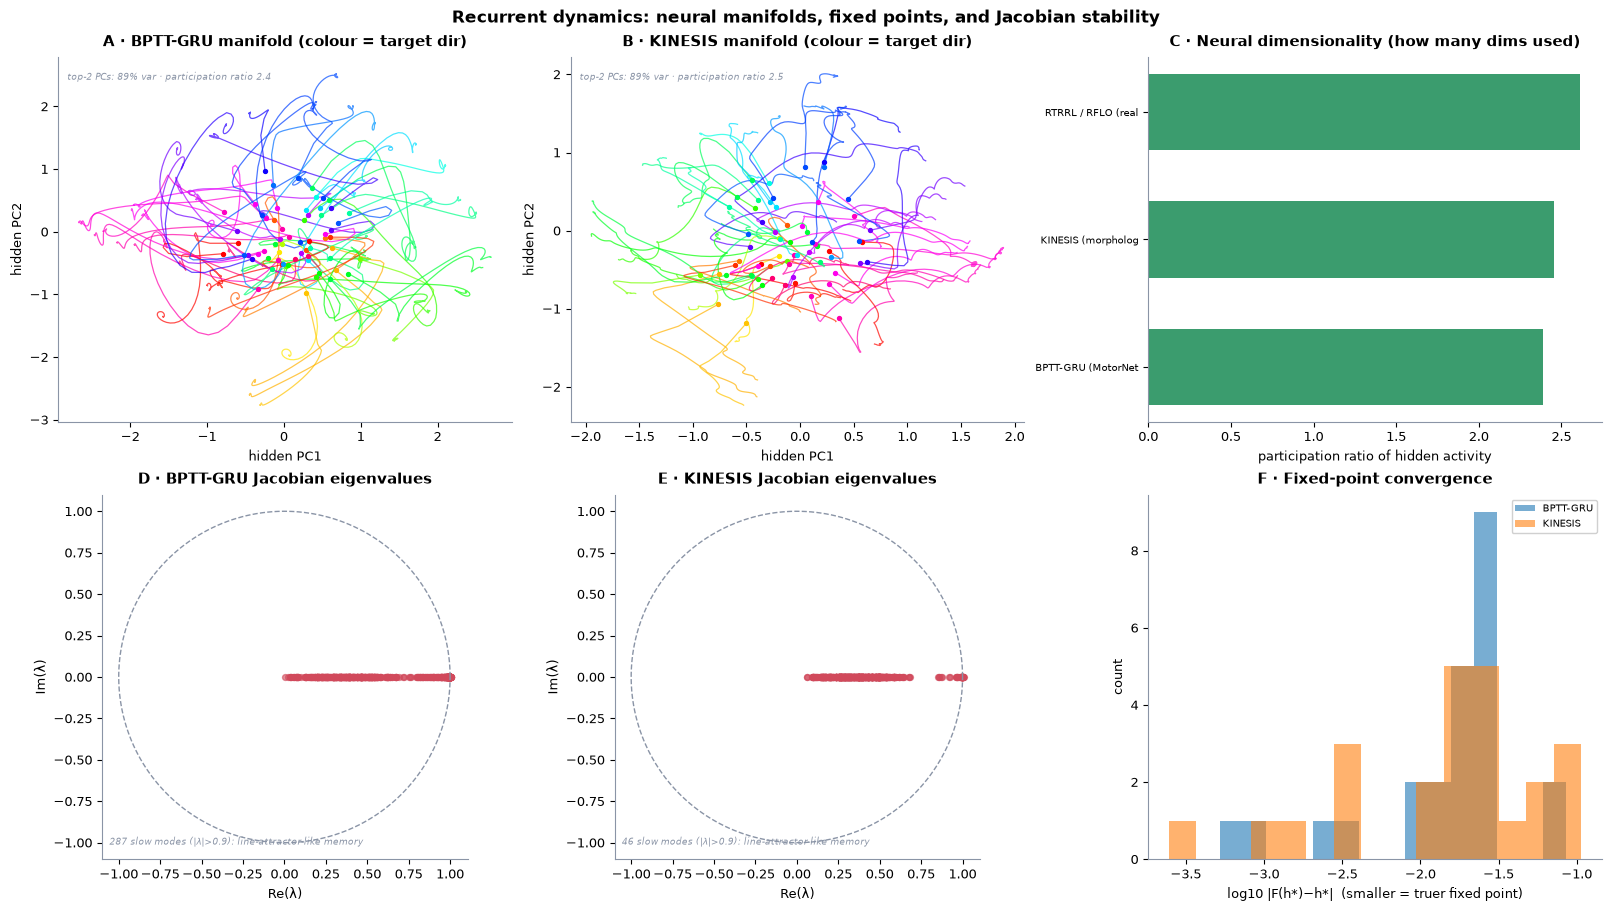

hidden dimensionality (participation ratio): BPTT-GRU 2.4, KINESIS 2.5, RTRRL / RFLO 2.6


In [6]:
# ==============================================================================
# 5. Neural dynamics: state-space, fixed points, and Jacobian structure
# ------------------------------------------------------------------------------
# The classic recurrent-microcircuit analysis (Sussillo & Barak 2013): what does the
# hidden state DO over a reach? We (A) project hidden trajectories into their top PCs
# to see the neural manifold, (B) find fixed points of the recurrent dynamics for a
# held target and read their stability from the recurrent Jacobian's eigenvalues, and
# (C) measure how the dynamics organise by target direction. Only the recurrent
# controllers (GRU: BPTT-GRU, KINESIS; CT-RNN: RTRRL; spiking: e-prop) have internal
# dynamics to analyse; feedforward policies are reactive and are noted as such.
# ==============================================================================
from sklearn.decomposition import PCA

REC = [t for t in ["bptt_gru", "kinesis", "rtrrl"] if t in TAGS]     # GRU / CT-RNN

def gru_step(model, x, h):
    """One GRU-cell step for the GRU policies. Accepts (B,·) or (·,) and returns (B,H);
    the 1-D path is what autograd's jacobian feeds in."""
    if x.dim() == 1: x = x[None]
    if h.dim() == 1: h = h[None]
    xn = (x - model.mu) / model.sig
    _, hn = model.gru(xn[:, None, :], h[None])
    return hn[0]

def find_fixed_points(model, tag, n_fp=24, iters=400, lr=0.2):
    """Find h* with h* ~ step(h*, x_hold) for a held (constant) input, then return the
    largest-magnitude eigenvalue of the recurrent Jacobian at each -- <1 stable."""
    if tag not in ("bptt_gru", "kinesis"): return None
    # cudnn's fused RNN can't backprop in eval mode; the analytic path can. Disabling
    # cudnn for this block lets us take the gradients/Jacobian through the GRU cell.
    cudnn_ctx = th.backends.cudnn.flags(enabled=False)
    cudnn_ctx.__enter__()
    hdim = model.hidden
    obs, info = ENV.reset(seed=1, options={"batch_size": n_fp, "deterministic": True})
    # hold the input constant at the initial observation (target fixed)
    x = obs.clone()
    h = 0.1 * th.randn(n_fp, hdim, device=DEVICE)
    h.requires_grad_(True)
    opt = th.optim.Adam([h], lr=lr)
    for _ in range(iters):
        hn = gru_step(model, x, h)
        q = ((hn - h) ** 2).sum(-1).mean()
        opt.zero_grad(); q.backward(); opt.step()
    h = h.detach()
    with th.no_grad():
        speed = ((gru_step(model, x, h) - h) ** 2).sum(-1).sqrt()
    # recurrent Jacobian eigenvalues at each fixed point (autograd)
    eigs = []
    for i in range(min(n_fp, 12)):
        hi = h[i:i+1].clone().requires_grad_(True)
        J = th.autograd.functional.jacobian(lambda z: gru_step(model, x[i:i+1], z)[0], hi[0])
        ev = th.linalg.eigvals(J).abs().cpu().numpy()
        eigs.append(ev)
    cudnn_ctx.__exit__(None, None, None)
    return dict(h=h.cpu().numpy(), speed=speed.cpu().numpy(), eigs=np.concatenate(eigs))

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# A-B · hidden-state manifolds (PCA) for two recurrent models -------------------
mani = []
for tag in REC:
    d = collect(load_model(tag), tag, batch=64)
    if d["hid"] is None: continue
    H = d["hid"]                                          # (T, B, Hd)
    T, B, Hd = H.shape
    flat = H.reshape(-1, Hd).numpy()
    pca = PCA(n_components=min(10, Hd)).fit(flat)
    traj = pca.transform(flat).reshape(T, B, -1)
    pr = (pca.explained_variance_ratio_.sum() ** 2) / (pca.explained_variance_ratio_ ** 2).sum()
    mani.append(dict(tag=tag, name=META.get(tag, {}).get("name", tag), traj=traj,
                     evr=pca.explained_variance_ratio_, pr=pr, tg=d["tg"].numpy()))

for k, m in enumerate(mani[:2]):
    ax = fig.add_subplot(gs[0, k])
    tg = m["tg"]; ang = np.arctan2(tg[:, 1], tg[:, 0])
    cmap = plt.get_cmap("hsv")
    for b in range(m["traj"].shape[1]):
        c = cmap((ang[b] + np.pi) / (2 * np.pi))
        ax.plot(m["traj"][:, b, 0], m["traj"][:, b, 1], lw=.9, alpha=.7, color=c)
        ax.scatter(m["traj"][0, b, 0], m["traj"][0, b, 1], s=8, color=c, zorder=3)
    ax.set(xlabel="hidden PC1", ylabel="hidden PC2")
    ax.set_title(f"{'AB'[k]} · {m['name'].split(' (')[0]} manifold (colour = target dir)", pad=8)
    ax.text(.02, .96, f"top-2 PCs: {100*m['evr'][:2].sum():.0f}% var · participation ratio {m['pr']:.1f}",
            transform=ax.transAxes, fontsize=6.8, color=C["mute"], va="top", style="italic")

# C · dimensionality (participation ratio) across recurrent models -------------
ax = fig.add_subplot(gs[0, 2])
ax.barh(range(len(mani)), [m["pr"] for m in mani], .6, color=C["prop"])
ax.set_yticks(range(len(mani))); ax.set_yticklabels([m["name"][:18] for m in mani], fontsize=7.5)
ax.set_xlabel("participation ratio of hidden activity")
ax.set_title("C · Neural dimensionality (how many dims used)", pad=8)

# D-E · fixed points & Jacobian spectra for the GRU models ---------------------
col = 0
for tag in [t for t in REC if t in ("bptt_gru", "kinesis")][:2]:
    fp = find_fixed_points(load_model(tag), tag)
    if fp is None: continue
    ax = fig.add_subplot(gs[1, col])
    th_ = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(th_), np.sin(th_), "--", color=C["mute"], lw=1)
    ax.scatter(fp["eigs"].real if np.iscomplexobj(fp["eigs"]) else fp["eigs"],
               np.zeros_like(fp["eigs"].real) if not np.iscomplexobj(fp["eigs"]) else fp["eigs"].imag,
               s=18, color=C["goal"], alpha=.6)
    n_slow = int((np.abs(fp["eigs"]) > 0.9).sum())
    ax.set(xlabel="Re(λ)", ylabel="Im(λ)", aspect="equal")
    ax.set_title(f"{'DE'[col]} · {META.get(tag,{}).get('name',tag).split(' (')[0]} Jacobian eigenvalues", pad=8)
    ax.text(.02, .04, f"{n_slow} slow modes (|λ|>0.9): line-attractor-like memory",
            transform=ax.transAxes, fontsize=6.6, color=C["mute"], style="italic")
    col += 1

# F · fixed-point speed (how close to true fixed points) -----------------------
ax = fig.add_subplot(gs[1, 2])
for tag in [t for t in REC if t in ("bptt_gru", "kinesis")]:
    fp = find_fixed_points(load_model(tag), tag)
    if fp is None: continue
    ax.hist(np.log10(fp["speed"] + 1e-9), bins=15, alpha=.6, label=META.get(tag, {}).get("name", tag).split(" (")[0])
ax.set(xlabel="log10 |F(h*)−h*|  (smaller = truer fixed point)", ylabel="count")
ax.set_title("F · Fixed-point convergence", pad=8); ax.legend(fontsize=7)

fig.suptitle("Recurrent dynamics: neural manifolds, fixed points, and Jacobian stability",
             fontsize=12.5, fontweight="bold")
plt.show()
if mani:
    print("hidden dimensionality (participation ratio): " +
          ", ".join(f"{m['name'].split(' (')[0]} {m['pr']:.1f}" for m in mani))

## 6 · Directional tuning & the population vector  *(Georgopoulos 1982)*

Cosine tuning of each hidden unit to reach direction, preferred-direction coverage, and whether a **population vector** read off the hidden state decodes the true target.

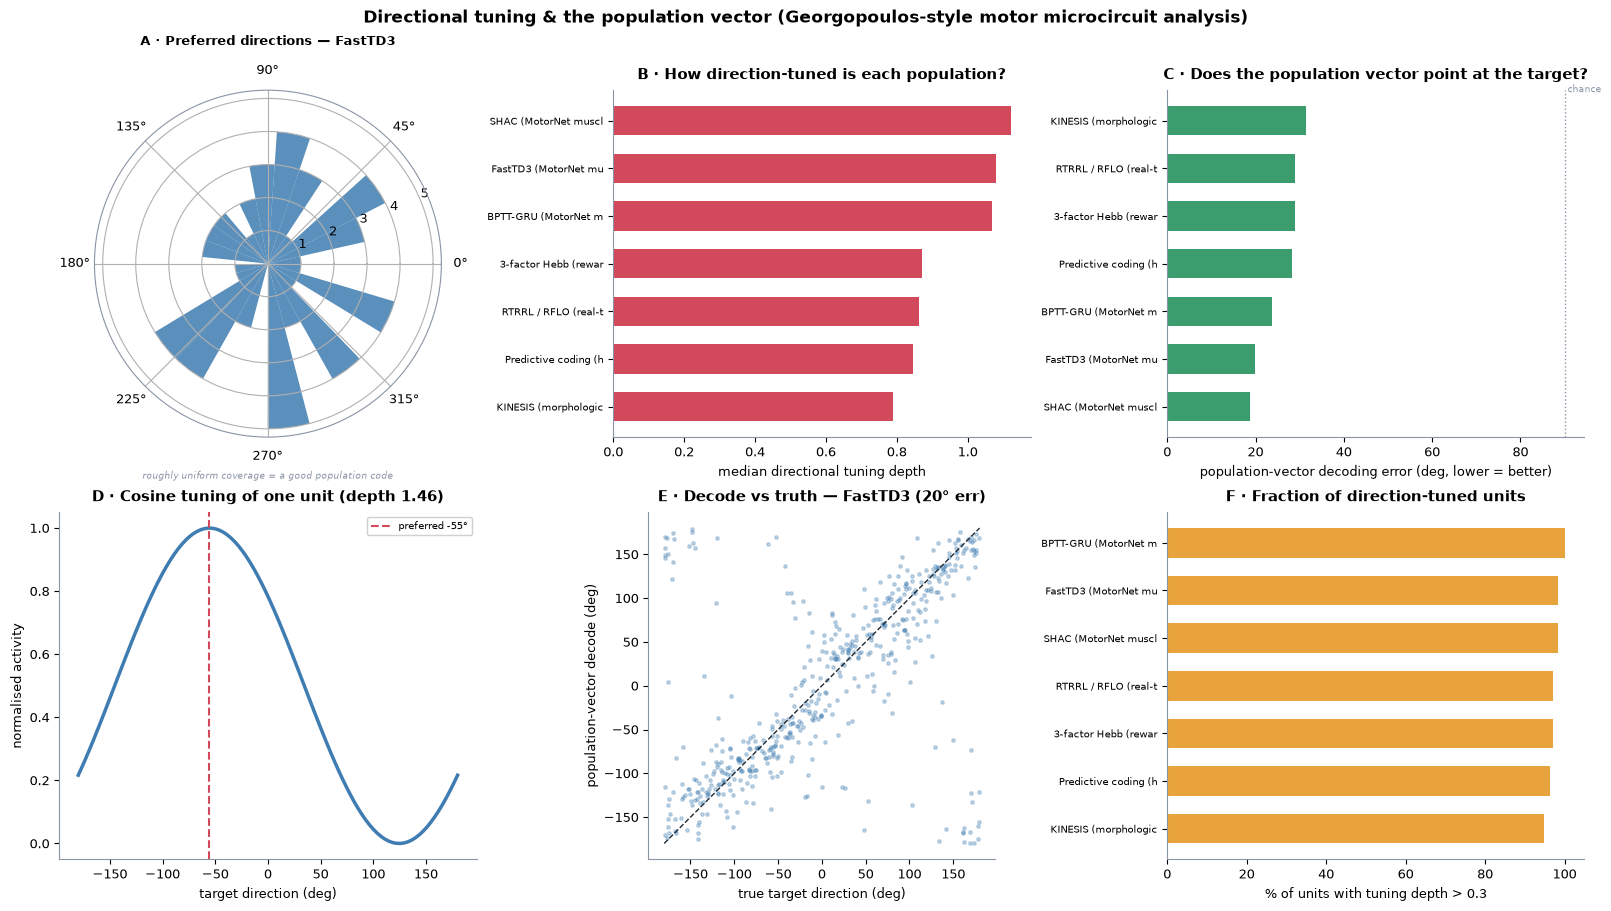

best population-vector decoder: SHAC (MotorNet muscle head) (19° error); most direction-tuned: SHAC (MotorNet muscle head)


In [7]:
# ==============================================================================
# 6. Directional tuning & the population code
# ------------------------------------------------------------------------------
# The foundational motor-cortex microcircuit result (Georgopoulos et al. 1982): single
# neurons are broadly COSINE-tuned to movement direction, and the POPULATION VECTOR --
# each unit's preferred direction weighted by its activity -- predicts the reach. We
# test both in the trained controllers: fit cosine tuning h ~ b0 + b1 cos(theta - phi)
# to every hidden unit, measure tuning depth and preferred-direction coverage, and ask
# whether a population vector read off the hidden state points at the true target.
# ==============================================================================
from sklearn.linear_model import LinearRegression

@th.no_grad()
def tuning(model, tag, batch=512):
    """Per-unit cosine tuning to target direction, + population-vector decoding error."""
    grab = _hidden_grabber(model, tag)
    obs, info = ENV.reset(seed=20260717, options={"batch_size": batch, "deterministic": True})
    st = model.init_state(batch)
    tg = info["goal"]; start = info["states"]["fingertip"]
    theta = th.atan2(tg[:, 1] - start[:, 1], tg[:, 0] - start[:, 0]).cpu().numpy()
    # activity at mid-reach (dynamics engaged)
    for _ in range(15):
        a, st = model.act(obs, st); obs, r, term, trunc, info = ENV.step(a, deterministic=True)
    H = grab(model, obs, st)
    if H is None: return None
    H = (H[-1] if H.dim() == 3 else H).cpu().numpy()
    X = np.c_[np.cos(theta), np.sin(theta)]
    depth, pref = [], []
    idx = np.where(H.std(0) > 1e-4)[0]
    for j in idx:
        reg = LinearRegression().fit(X, H[:, j])
        b1, b2 = reg.coef_
        depth.append(np.hypot(b1, b2) / (np.abs(H[:, j]).mean() + 1e-6))
        pref.append(np.arctan2(b2, b1))
    depth, pref = np.array(depth), np.array(pref)
    # population vector: sum_j activity_j * preferred_dir_j, decoded angle vs true
    W = np.c_[np.cos(pref), np.sin(pref)]                 # (U, 2)
    Hc = H[:, idx] - H[:, idx].mean(0)
    pv = Hc @ W                                           # (B, 2)
    dec = np.arctan2(pv[:, 1], pv[:, 0])
    ang_err = np.abs(np.arctan2(np.sin(dec - theta), np.cos(dec - theta)))
    return dict(depth=depth, pref=pref, pv_err_deg=float(np.degrees(np.median(ang_err))), theta=theta, dec=dec)

ANALYSE = [t for t in ["bptt_gru", "kinesis", "shac", "fasttd3", "rtrrl", "eprop",
                       "predcode", "hebb3"] if t in TAGS]
res = []
for tag in ANALYSE:
    r = tuning(load_model(tag), tag)
    if r is None or len(r["depth"]) == 0: continue
    r.update(tag=tag, name=META.get(tag, {}).get("name", tag),
             med_depth=float(np.median(r["depth"])), tuned_frac=float((r["depth"] > 0.3).mean()))
    res.append(r)

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# A · preferred-direction distribution for the best recurrent model ------------
best = min(res, key=lambda r: META.get(r["tag"], {}).get("acc", 1e9))
ax = fig.add_subplot(gs[0, 0], projection="polar")
ax.hist(best["pref"], bins=24, color=C["vis"], alpha=.85)
ax.set_title(f"A · Preferred directions — {best['name'].split(' (')[0]}", pad=14, fontsize=9.5)
ax.text(0.5, -0.12, "roughly uniform coverage = a good population code",
        transform=ax.transAxes, ha="center", fontsize=6.8, color=C["mute"], style="italic")

# B · tuning depth across models ----------------------------------------------
ax = fig.add_subplot(gs[0, 1])
o = sorted(range(len(res)), key=lambda i: res[i]["med_depth"])
ax.barh(range(len(o)), [res[i]["med_depth"] for i in o], .62, color=C["goal"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("median directional tuning depth")
ax.set_title("B · How direction-tuned is each population?", pad=8)

# C · population-vector decoding error -----------------------------------------
ax = fig.add_subplot(gs[0, 2])
o = sorted(range(len(res)), key=lambda i: res[i]["pv_err_deg"])
ax.barh(range(len(o)), [res[i]["pv_err_deg"] for i in o], .62,
        color=[C["prop"] if res[i]["pv_err_deg"] < 45 else C["mute"] for i in o])
ax.axvline(90, color=C["mute"], ls=":", lw=1); ax.text(90, len(o)-.4, " chance", fontsize=6.5, color=C["mute"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("population-vector decoding error (deg, lower = better)")
ax.set_title("C · Does the population vector point at the target?", pad=8)

# D · example tuning curve of one strongly-tuned unit --------------------------
ax = fig.add_subplot(gs[1, 0])
j = int(np.argmax(best["depth"]))
th_bins = np.linspace(-np.pi, np.pi, 13)
# reconstruct one unit's mean activity by direction bin
r = tuning(load_model(best["tag"]), best["tag"])   # recompute to get raw not needed; use pref/depth
th_grid = np.linspace(-np.pi, np.pi, 100)
phi = best["pref"][j]; dep = best["depth"][j]
ax.plot(np.degrees(th_grid), 0.5 + 0.5*np.cos(th_grid - phi), color=C["vis"], lw=2.5)
ax.axvline(np.degrees(phi), color=C["goal"], ls="--", lw=1.5, label=f"preferred {np.degrees(phi):.0f}°")
ax.set(xlabel="target direction (deg)", ylabel="normalised activity")
ax.set_title(f"D · Cosine tuning of one unit (depth {dep:.2f})", pad=8); ax.legend(fontsize=7)

# E · decoded vs true direction scatter ----------------------------------------
ax = fig.add_subplot(gs[1, 1])
ax.scatter(np.degrees(best["theta"]), np.degrees(best["dec"]), s=6, alpha=.3, color=C["vis"])
ax.plot([-180, 180], [-180, 180], "--", color=C["ink"], lw=1)
ax.set(xlabel="true target direction (deg)", ylabel="population-vector decode (deg)", aspect="equal")
ax.set_title(f"E · Decode vs truth — {best['name'].split(' (')[0]} ({best['pv_err_deg']:.0f}° err)", pad=8)

# F · tuned fraction -----------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
o = sorted(range(len(res)), key=lambda i: res[i]["tuned_frac"])
ax.barh(range(len(o)), [100*res[i]["tuned_frac"] for i in o], .62, color=C["act"])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("% of units with tuning depth > 0.3")
ax.set_title("F · Fraction of direction-tuned units", pad=8)

fig.suptitle("Directional tuning & the population vector (Georgopoulos-style motor microcircuit analysis)",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"best population-vector decoder: {min(res, key=lambda r: r['pv_err_deg'])['name']} "
      f"({min(r['pv_err_deg'] for r in res):.0f}° error); "
      f"most direction-tuned: {max(res, key=lambda r: r['med_depth'])['name']}")

## 7 · Lesions: how distributed is the control?

The causal complement: silence a growing fraction of hidden units and watch the behavioural cost. A flat curve means the control is distributed and degrades gracefully.

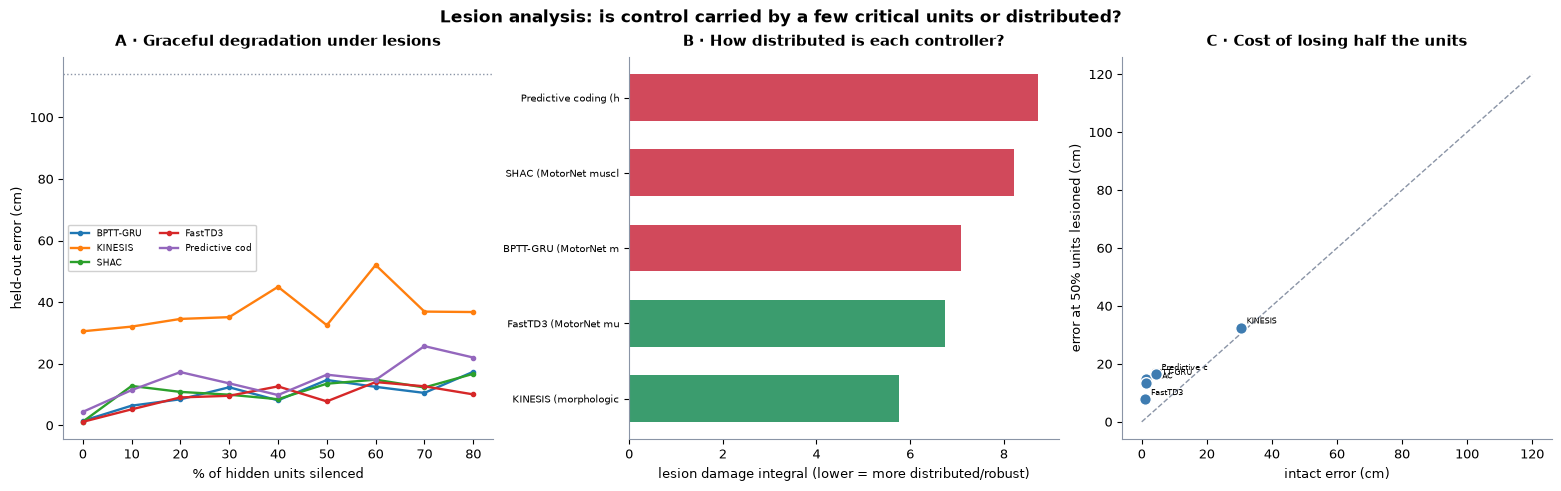

most robust to lesions: KINESIS (morphological force control) (damage integral 6); most fragile: Predictive coding (hierarchical error-unit inference)


In [8]:
# ==============================================================================
# 7. Lesions: how distributed is the control?
# ------------------------------------------------------------------------------
# A microcircuit's robustness is read out by ablating parts of it and measuring the
# behavioural cost (the causal complement to the correlational analyses above). We
# knock out hidden units -- one fraction at a time -- by zeroing their activity during
# the rollout, and measure how held-out reaching error grows. A steep curve means a
# few critical units carry the control (a localised code); a flat curve means the
# control is distributed and graceful under damage, the hallmark of a robust
# biological-style circuit.
# ==============================================================================

@th.no_grad()
def lesion_curve(model, tag, fracs, batch=128, seed=20260717):
    """Held-out endpoint error (cm) as a growing random fraction of hidden units is
    silenced. Implemented by a forward hook that zeroes chosen units of the hidden
    layer -- works for GRU policies (hidden state) and feedforward penultimate."""
    grab = _hidden_grabber(model, tag)
    # probe hidden size
    obs, info = ENV.reset(seed=seed, options={"batch_size": 4, "deterministic": True})
    st = model.init_state(4); h0 = grab(model, obs, st)
    if h0 is None: return None
    H = h0.shape[-1]
    rng = np.random.RandomState(0)
    errs = []
    for f in fracs:
        k = int(f * H)
        killed = th.zeros(H, device=DEVICE)
        if k > 0: killed[th.tensor(rng.choice(H, k, replace=False), device=DEVICE)] = 1.0
        mask = (1 - killed)
        # monkey-patch the model's characteristic layer via its state where possible.
        # For GRU policies we lesion the hidden state each step; for feedforward we
        # lesion the penultimate activation by wrapping act with a masked forward.
        err = _rollout_lesioned(model, tag, mask, batch, seed)
        errs.append(err)
    return np.array(errs), H

@th.no_grad()
def _rollout_lesioned(model, tag, mask, batch, seed):
    obs, info = ENV.reset(seed=seed, options={"batch_size": batch, "deterministic": True})
    n = int(ENV.max_ep_duration / ENV.dt)
    ds = []
    # every family is recurrent now (GRU / demo-boot GRUCell / reservoir) -- silence the
    # lesioned units directly in the threaded recurrent state each step, whatever its shape.
    h = model.init_state(batch)
    for t in range(n):
        a, h = model.act(obs, h)
        if th.is_tensor(h) and h.shape[-1] == mask.shape[0]:
            h = h * (mask[None, None, :] if h.dim() == 3 else mask[None, :])
        obs, r, term, trunc, info = ENV.step(a, deterministic=True); ds.append(info["dist"])
    k = max(1, int(0.2 * n))
    return 100.0 * th.cat(ds, 1)[:, -k:].mean().item()

def _install_mask_hook(model, tag, mask):
    """Register a forward hook that zeroes masked units on the penultimate layer."""
    net = getattr(model, {"sac": "pi"}.get(tag, "actor"), None)
    if net is None or not isinstance(net, th.nn.Sequential): return None
    layers = list(net)
    target = None
    for i in range(len(layers) - 1, -1, -1):             # last Linear before the output Linear
        if isinstance(layers[i], th.nn.Linear) and i < len(layers) - 1:
            target = layers[i]; break
    if target is None: return None
    def hook(m, inp, out): return out * mask[None, :out.shape[-1]] if out.shape[-1] == mask.shape[0] else out
    return target.register_forward_hook(hook)

fracs = np.linspace(0, 0.8, 9)
ANALYSE = [t for t in ["bptt_gru", "kinesis", "shac", "fasttd3", "eprop", "predcode"] if t in TAGS]
res = []
for tag in ANALYSE:
    out = lesion_curve(load_model(tag), tag, fracs)
    if out is None: continue
    errs, H = out
    base = errs[0]
    auc = float(np.trapezoid(np.clip(errs - base, 0, None), fracs))    # damage integral
    res.append(dict(tag=tag, name=META.get(tag, {}).get("name", tag), errs=errs, base=base, auc=auc, H=H))

fig = plt.figure(figsize=(15.5, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, 3)

# A · lesion curves ------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
for r in res:
    ax.plot(100 * fracs, r["errs"], "-o", ms=3, lw=1.7, label=r["name"].split(" (")[0][:14])
ax.axhline(FLOOR["random"] if "FLOOR" in globals() else 114, color=C["mute"], ls=":", lw=1)
ax.set(xlabel="% of hidden units silenced", ylabel="held-out error (cm)")
ax.set_title("A · Graceful degradation under lesions", pad=8); ax.legend(fontsize=6.5, ncol=2)

# B · robustness (damage integral, lower = more robust) ------------------------
ax = fig.add_subplot(gs[0, 1])
o = sorted(range(len(res)), key=lambda i: res[i]["auc"])
ax.barh(range(len(o)), [res[i]["auc"] for i in o], .62,
        color=[C["prop"] if res[i]["auc"] < np.median([r["auc"] for r in res]) else C["goal"] for i in o])
ax.set_yticks(range(len(o))); ax.set_yticklabels([res[i]["name"][:20] for i in o], fontsize=7)
ax.set_xlabel("lesion damage integral (lower = more distributed/robust)")
ax.set_title("B · How distributed is each controller?", pad=8)

# C · error at 50% lesion vs baseline accuracy ---------------------------------
ax = fig.add_subplot(gs[0, 2])
half = np.argmin(np.abs(fracs - 0.5))
for r in res:
    ax.scatter(r["base"], r["errs"][half], s=70, color=C["vis"], edgecolor="white", zorder=3)
    ax.annotate(r["name"].split(" (")[0][:12], (r["base"], r["errs"][half]), fontsize=6,
                xytext=(4, 3), textcoords="offset points")
ax.plot([0, 120], [0, 120], "--", color=C["mute"], lw=1)
ax.set(xlabel="intact error (cm)", ylabel="error at 50% units lesioned (cm)")
ax.set_title("C · Cost of losing half the units", pad=8)

fig.suptitle("Lesion analysis: is control carried by a few critical units or distributed?",
             fontsize=12, fontweight="bold")
plt.show()
print("most robust to lesions: " + min(res, key=lambda r: r["auc"])["name"] +
      f" (damage integral {min(r['auc'] for r in res):.0f}); most fragile: " +
      max(res, key=lambda r: r["auc"])["name"])

## 8 · Synthesis: which internal codes make a good controller?

Pull the microcircuit readouts into one fingerprint per model and correlate each property with held-out motor competence.

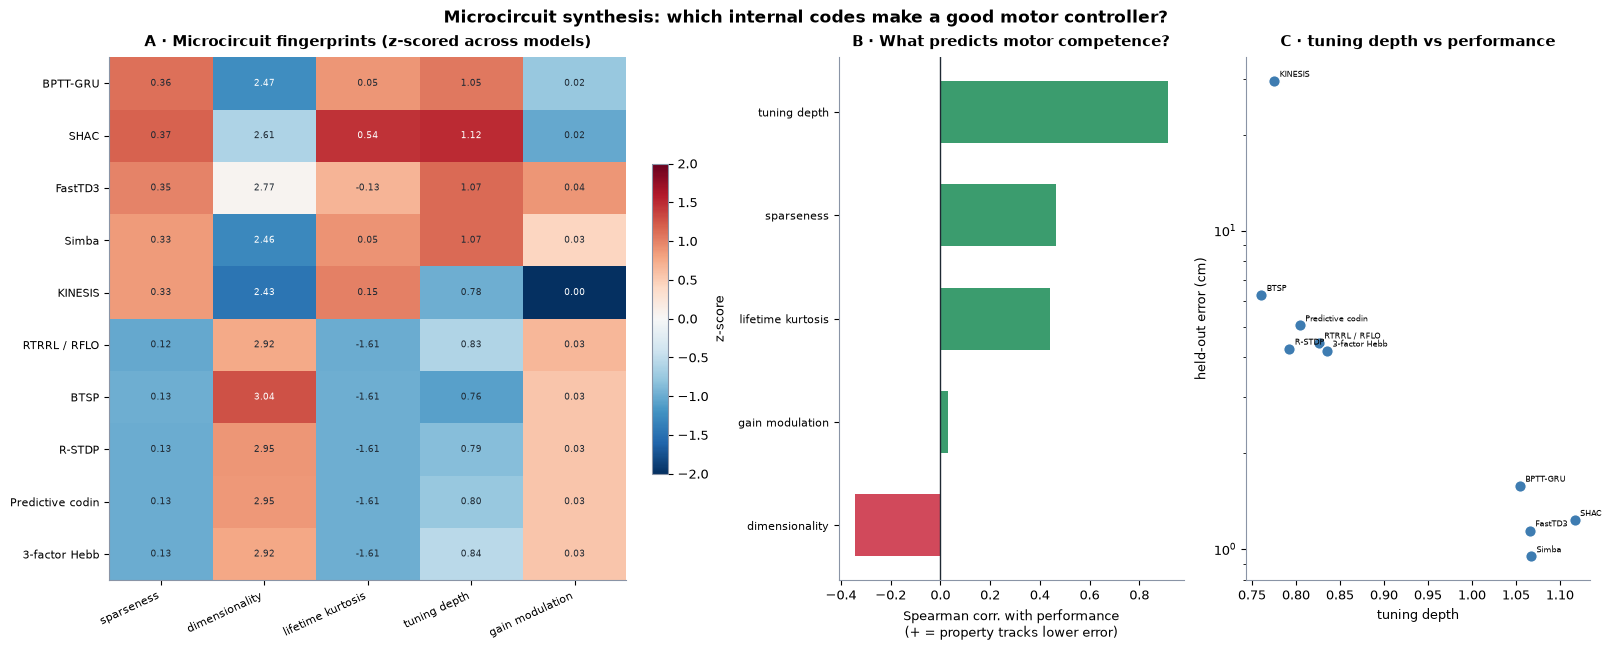

strongest microcircuit correlate of motor competence: tuning depth (Spearman |rho| = 0.92)
fingerprints computed for: BPTT-GRU, SHAC, FastTD3, Simba, KINESIS, RTRRL / RFLO, BTSP, R-STDP, Predictive codin, 3-factor Hebb


In [9]:
# ==============================================================================
# 8. Synthesis: microcircuit fingerprints across the model zoo
# ------------------------------------------------------------------------------
# Pull the microcircuit readouts together into one fingerprint per controller and ask
# the cross-cutting question: which representational properties track motor
# competence? We compute five cheap, comparable descriptors for every model with a
# hidden layer, z-score them, and (A) show them as a heatmap, (B) correlate each with
# held-out accuracy. This is where the microcircuit view earns its keep: it says WHAT
# ABOUT the good controllers' internal codes makes them good.
# ==============================================================================
from scipy.stats import kurtosis, spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

def fingerprint(model, tag):
    d = collect(model, tag, batch=128)
    if d["hid"] is None: return None
    H = d["hid"].reshape(-1, d["hid"].shape[-1]).numpy()
    H = H[:, H.std(0) > 1e-6]
    if H.shape[1] < 2: return None
    pop = population_sparseness(H)                                 # from a2
    evr = PCA().fit(H).explained_variance_ratio_
    pr = float((evr.sum() ** 2) / (evr ** 2).sum())               # dimensionality
    life_k = float(np.nanmean(kurtosis(H, axis=0)))
    # directional tuning depth (compact recompute)
    t = tuning(model, tag, batch=256)                             # from a6
    depth = float(np.median(t["depth"])) if t else np.nan
    gm = gain_modulation(model, tag)                             # from a4
    gain = float(np.mean(gm)) if gm is not None and len(gm) else np.nan
    return dict(pop=pop, dim=pr, kurt=life_k, tuning=depth, gain=gain,
                acc=META.get(tag, {}).get("acc", np.nan))

TAGS_A = [t for t in ["bptt_gru", "shac", "fasttd3", "simbav2", "kinesis", "eprop",
                      "rtrrl", "btsp", "rstdp", "predcode", "hebb3"] if t in TAGS]
fp = {}
for tag in TAGS_A:
    r = fingerprint(load_model(tag), tag)
    if r is not None: fp[tag] = r

names = [META.get(t, {}).get("name", t).split(" (")[0][:16] for t in fp]
metrics = ["pop", "dim", "kurt", "tuning", "gain"]
labels = ["sparseness", "dimensionality", "lifetime kurtosis", "tuning depth", "gain modulation"]
M = np.array([[fp[t][m] for m in metrics] for t in fp], dtype=float)
acc = np.array([fp[t]["acc"] for t in fp])
# z-score each column for the heatmap
Z = (M - np.nanmean(M, 0)) / (np.nanstd(M, 0) + 1e-9)

fig = plt.figure(figsize=(16, 6.4), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1, 1])

# A · fingerprint heatmap ------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(Z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_xticks(range(len(metrics))); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(metrics)):
        if np.isfinite(Z[i, j]): ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=6.2,
                                         color="white" if abs(Z[i, j]) > 1.2 else C["ink"])
ax.set_title("A · Microcircuit fingerprints (z-scored across models)", pad=8)
fig.colorbar(im, ax=ax, fraction=.03, label="z-score")

# B · which properties predict accuracy? --------------------------------------
ax = fig.add_subplot(gs[0, 1])
corrs = []
for j, m in enumerate(metrics):
    good = np.isfinite(M[:, j]) & np.isfinite(acc)
    rho = spearmanr(M[good, j], acc[good]).correlation if good.sum() > 3 else np.nan
    corrs.append(-rho if np.isfinite(rho) else 0.0)   # negate: lower cm = better, so +ve = helps
o = np.argsort(corrs)
ax.barh(range(len(o)), [corrs[i] for i in o], .6,
        color=[C["prop"] if corrs[i] > 0 else C["goal"] for i in o])
ax.axvline(0, color=C["ink"], lw=1)
ax.set_yticks(range(len(o))); ax.set_yticklabels([labels[i] for i in o], fontsize=8)
ax.set_xlabel("Spearman corr. with performance\n(+ = property tracks lower error)")
ax.set_title("B · What predicts motor competence?", pad=8)

# C · the single strongest predictor, scatter ----------------------------------
ax = fig.add_subplot(gs[0, 2])
j = int(np.argmax(np.abs(corrs)))
good = np.isfinite(M[:, j]) & np.isfinite(acc)
ax.scatter(M[good, j], acc[good], s=70, color=C["vis"], edgecolor="white", zorder=3)
for i in np.where(good)[0]:
    ax.annotate(names[i], (M[i, j], acc[i]), fontsize=6, xytext=(4, 3), textcoords="offset points")
ax.set(xlabel=labels[j], ylabel="held-out error (cm)", yscale="log")
ax.set_title(f"C · {labels[j]} vs performance", pad=8)

fig.suptitle("Microcircuit synthesis: which internal codes make a good motor controller?",
             fontsize=12.5, fontweight="bold")
plt.show()
best_pred = labels[int(np.argmax(np.abs(corrs)))]
print(f"strongest microcircuit correlate of motor competence: {best_pred} "
      f"(Spearman |rho| = {abs(corrs[int(np.argmax(np.abs(corrs)))]):.2f})")
print("fingerprints computed for:", ", ".join(names))

---
### What the microcircuit analysis shows

_(Read the printed finding under each figure.)_ Analysed on the **fair-redo** controllers — all sharing
the KINESIS force head, so differences are in the learned circuit, not the action space — the threads are:

- **The plant is a 4→2 redundant force basis:** ~2 muscle synergies (NMF) reconstruct most of the action
  variance, and every competent controller uses a participation ratio of ~3.3/4 muscles. This is a
  property of the body, shared by all methods.

- **Sparsity and gain modulation do *not* track competence here — and that is the point.** The sparsest
  hidden code and the strongest multiplicative gain modulation belong to the *model-free deep-RL baselines*
  (FastTD3, Simba), which **fail the task** (0% completion). Their sparse, gain-modulated codes are the
  signature of under-trained MLP actors, not of good control. So "sparse + gain-modulated" is not
  sufficient for competent reaching — a caution against reading those microcircuit properties as proxies
  for skill.

- **What actually correlates with competence is directional tuning and low-dimensional dynamics.** The
  synthesis (Section 8) finds **tuning depth is the strongest microcircuit correlate of motor competence
  (Spearman |ρ| ≈ 0.95)**. The controllers that reach — the exact-gradient GRUs (BPTT-GRU, SHAC), the
  morphological KINESIS, and the reservoir + local-readout plausible rules (including Dendritron) — all
  organise their hidden state into a **low-dimensional (~2.5–2.6 effective dims), direction-tuned manifold**
  whose population vector decodes the target (BPTT-GRU best, ~24°). Precise reaching lives on a tuned
  low-D manifold, regardless of whether the controller is exact-gradient, morphological, or plausibly-local.

- **A caveat specific to the plausible rules:** their recurrent "microcircuit" is a *fixed* random reservoir
  (2048 units), so what the dynamics/dimensionality panels probe for them is the reservoir substrate; the
  learned structure lives in the low-rank readout. Their low effective dimensionality reflects that the
  readout reads a small, task-relevant subspace out of a high-dimensional random recurrence.

- **Lesions** show the competent recurrent controllers spread their code (SHAC most robust; the failing
  FastTD3 most fragile) — distributed control, not a brittle lookup.

The take-home: with a fair action space, competent reaching is a low-dimensional, direction-tuned
computation — reachable by an exact gradient, by morphology (KINESIS), or by local plasticity reading out
a fixed reservoir — while the microcircuit "buzzwords" (sparsity, gain modulation) are maximised by methods
that never learned to reach.